In [2]:
#Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows (optional)
pd.set_option('display.max_rows', None)

In [10]:
# Step 2: Load the Excel File & Understanding

file_path = r"C:\Users\Santanu Biswas\Downloads\Phonepe_Raw_Data.xlsx"

xls = pd.ExcelFile(file_path)

print(xls.sheet_names)

['State_Txn and Users', 'State_TxnSplit', 'State_DeviceData', 'District_Txn and Users', 'District Demographics', 'Admin']


In [56]:
# Step 3: Read All Sheets into DataFrames
all_sheets = pd.read_excel(
    file_path,
    sheet_name=None
)
for sheet_name in all_sheets.keys():
    print(sheet_name)


State_Txn and Users
State_TxnSplit
State_DeviceData
District_Txn and Users
District Demographics
Admin


C:\Users\Santanu Biswas\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [14]:
# Step 4: Create Individual DataFrames
df_State_Txn_Users = all_sheets['State_Txn and Users']

df_State_TxnSplit = all_sheets['State_TxnSplit']

df_State_DeviceData = all_sheets['State_DeviceData']

df_District_Txn_Users = all_sheets['District_Txn and Users']

df_District_Demographics = all_sheets['District Demographics']

In [17]:
print(df_State_Txn_Users.shape)
print(df_State_TxnSplit.shape)
print(df_State_DeviceData.shape)
print(df_District_Txn_Users.shape)
print(df_District_Demographics.shape)

(504, 8)
(2514, 7)
(5544, 6)
(10248, 10)
(742, 8)


In [18]:
for name, df in all_sheets.items():
    print(f"\n{'='*50}")
    print(f"Dataset: {name}")
    print(f"{'='*50}")

    print("Shape:", df.shape)
    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())


Dataset: State_Txn and Users
Shape: (504, 8)

Missing Values:
State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

Duplicate Rows:
0

Dataset: State_TxnSplit
Shape: (2514, 7)

Missing Values:
State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount (INR)        0
ATV (INR)           0
dtype: int64

Duplicate Rows:
0

Dataset: State_DeviceData
Shape: (5544, 6)

Missing Values:
State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64

Duplicate Rows:
0

Dataset: District_Txn and Users
Shape: (10248, 10)

Missing Values:
State                0
Year                 0
Quarter              0
District             0
Code                28
Transactions         0
Amount (INR)         0
ATV (INR)            4
Regist

In [20]:
# Step 8: Create Dataset Summary Table
summary = pd.DataFrame({
    'Dataset': all_sheets.keys(),
    'Rows': [df.shape[0] for df in all_sheets.values()],
    'Columns': [df.shape[1] for df in all_sheets.values()],
    'Missing Values': [df.isnull().sum().sum() for df in all_sheets.values()],
    'Duplicate Rows': [df.duplicated().sum() for df in all_sheets.values()]
})

summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,State_Txn and Users,504,8,1,0
1,State_TxnSplit,2514,7,0,0
2,State_DeviceData,5544,6,0,0
3,District_Txn and Users,10248,10,32,0
4,District Demographics,742,8,0,0
5,Admin,42,6,128,1


In [21]:
df_State_Txn_Users[df_State_Txn_Users.isnull().any(axis=1)]

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,NaN,0.0,18363733,957709447


In [22]:
df_District_Txn_Users[df_District_Txn_Users.isnull().any(axis=1)]

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
224,Arunachal Pradesh,2018,1,Anjaw,AR01,0,0.000000e+00,NaN,278,0
241,Arunachal Pradesh,2018,1,Shi Yomi,AR17,0,0.000000e+00,NaN,49,0
266,Arunachal Pradesh,2018,2,Shi Yomi,AR17,0,0.000000e+00,NaN,80,0
291,Arunachal Pradesh,2018,3,Shi Yomi,AR17,0,0.000000e+00,NaN,118,0
3133,Jammu & Kashmir,2018,1,Mirpur,NaN,1320,3.052182e+06,2312.259022,544,0
3134,Jammu & Kashmir,2018,1,Muzaffarabad,NaN,13,1.455980e+04,1119.984877,41,0
3155,Jammu & Kashmir,2018,2,Mirpur,NaN,1885,4.089199e+06,2169.336200,795,0
3156,Jammu & Kashmir,2018,2,Muzaffarabad,NaN,75,3.688235e+05,4917.646448,57,0
3177,Jammu & Kashmir,2018,3,Mirpur,NaN,2789,7.804798e+06,2798.421577,1133,0
3178,Jammu & Kashmir,2018,3,Muzaffarabad,NaN,211,5.818788e+05,2757.719318,89,0


In [23]:
(df_State_Txn_Users.isnull().sum().sum() / len(df_State_Txn_Users)) * 100

np.float64(0.1984126984126984)

In [24]:
(df_District_Txn_Users.isnull().sum().sum() / len(df_District_Txn_Users)) * 100

np.float64(0.312256049960968)

In [30]:
# Droping the null values 
df_State_Txn_Users.dropna(inplace=True)

In [31]:
df_District_Txn_Users.dropna(inplace=True)

In [33]:
print(df_State_Txn_Users.isnull().sum().sum())


0


In [34]:

print(df_District_Txn_Users.isnull().sum().sum())

0


In [62]:
all_sheets['State_Txn and Users'] = df_State_Txn_Users
all_sheets['District_Txn and Users'] = df_District_Txn_Users

In [63]:
for name, df in all_sheets.items():
    print(name, ":", df.isnull().sum().sum())

State_Txn and Users : 0
State_TxnSplit : 0
State_DeviceData : 0
District_Txn and Users : 0
District Demographics : 0
Admin : 128


In [64]:
summary = pd.DataFrame({
    'Dataset': all_sheets.keys(),
    'Rows': [df.shape[0] for df in all_sheets.values()],
    'Columns': [df.shape[1] for df in all_sheets.values()],
    'Missing Values': [df.isnull().sum().sum() for df in all_sheets.values()],
    'Duplicate Rows': [df.duplicated().sum() for df in all_sheets.values()]
})

summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,State_Txn and Users,503,8,0,0
1,State_TxnSplit,2514,7,0,0
2,State_DeviceData,5544,6,0,0
3,District_Txn and Users,10216,10,0,0
4,District Demographics,742,8,0,0
5,Admin,42,6,128,1


In [65]:
all_sheets.keys()

dict_keys(['State_Txn and Users', 'State_TxnSplit', 'State_DeviceData', 'District_Txn and Users', 'District Demographics', 'Admin'])

In [66]:
df_State_Txn_Users = all_sheets['State_Txn and Users']

df_State_TxnSplit = all_sheets['State_TxnSplit']

df_State_DeviceData = all_sheets['State_DeviceData']

df_District_Txn_Users = all_sheets['District_Txn and Users']

df_District_Demographics = all_sheets['District Demographics']

In [72]:
summary = pd.DataFrame({
    'Dataset': [
        'State_Txn_Users',
        'State_TxnSplit',
        'State_DeviceData',
        'District_Txn_Users',
        'District_Demographics'
    ],
    'Rows': [
        df_State_Txn_Users.shape[0],
        df_State_TxnSplit.shape[0],
        df_State_DeviceData.shape[0],
        df_District_Txn_Users.shape[0],
        df_District_Demographics.shape[0]
    ],
    'Columns': [
        df_State_Txn_Users.shape[1],
        df_State_TxnSplit.shape[1],
        df_State_DeviceData.shape[1],
        df_District_Txn_Users.shape[1],
        df_District_Demographics.shape[1]
    ],
    'Missing Values': [
        df_State_Txn_Users.isnull().sum().sum(),
        df_State_TxnSplit.isnull().sum().sum(),
        df_State_DeviceData.isnull().sum().sum(),
        df_District_Txn_Users.isnull().sum().sum(),
        df_District_Demographics.isnull().sum().sum()
    ],
    'Duplicate Rows': [
        df_State_Txn_Users.duplicated().sum(),
        df_State_TxnSplit.duplicated().sum(),
        df_State_DeviceData.duplicated().sum(),
        df_District_Txn_Users.duplicated().sum(),
        df_District_Demographics.duplicated().sum()
    ]
})

summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,State_Txn_Users,503,8,0,0
1,State_TxnSplit,2514,7,0,0
2,State_DeviceData,5544,6,0,0
3,District_Txn_Users,10216,10,0,0
4,District_Demographics,742,8,0,0


In [74]:
# EDA workflow.
# Phase 1: Understand Each Dataset
for name, df in {
    'State_Txn_Users': df_State_Txn_Users,
    'State_TxnSplit': df_State_TxnSplit,
    'State_DeviceData': df_State_DeviceData,
    'District_Txn_Users': df_District_Txn_Users,
    'District_Demographics': df_District_Demographics
}.items():
    
    print("\n" + "="*60)
    print(name)
    print("="*60)

    display(df.head())
    print(df.info())



State_Txn_Users


,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


<class 'pandas.core.frame.DataFrame'>
Index: 503 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             503 non-null    object 
 1   Year              503 non-null    int64  
 2   Quarter           503 non-null    int64  
 3   Transactions      503 non-null    int64  
 4   Amount (INR)      503 non-null    float64
 5   ATV (INR)         503 non-null    float64
 6   Registered Users  503 non-null    int64  
 7   App Opens         503 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 35.4+ KB
None

State_TxnSplit


,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6487.790112
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,1518.480432
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,321.255149
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05,721.444790


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             2514 non-null   object 
 1   Year              2514 non-null   int64  
 2   Quarter           2514 non-null   int64  
 3   Transaction Type  2514 non-null   object 
 4   Transactions      2514 non-null   int64  
 5   Amount (INR)      2514 non-null   float64
 6   ATV (INR)         2514 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 137.6+ KB
None

State_DeviceData


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             5544 non-null   object 
 1   Year              5544 non-null   int64  
 2   Quarter           5544 non-null   int64  
 3   Brand             5544 non-null   object 
 4   Registered Users  5544 non-null   int64  
 5   Percentage        5544 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 260.0+ KB
None

District_Txn_Users


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


<class 'pandas.core.frame.DataFrame'>
Index: 10216 entries, 0 to 10247
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             10216 non-null  object 
 1   Year              10216 non-null  int64  
 2   Quarter           10216 non-null  int64  
 3   District          10216 non-null  object 
 4   Code              10216 non-null  object 
 5   Transactions      10216 non-null  int64  
 6   Amount (INR)      10216 non-null  float64
 7   ATV (INR)         10216 non-null  float64
 8   Registered Users  10216 non-null  int64  
 9   App Opens         10216 non-null  int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 877.9+ KB
None

District_Demographics


,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
1,Andhra Pradesh,Chittoor,Chittoor,4170468,15152.0,275,AP02,Chittoor
2,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.0,477,AP03,East Godavari
3,Andhra Pradesh,Guntur,Guntur,4889230,11391.0,429,AP04,Guntur
4,Andhra Pradesh,YSR,Kadapa,2884524,15359.0,188,AP13,YSR


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           742 non-null    object 
 1   District        742 non-null    object 
 2   Headquarters    742 non-null    object 
 3   Population      742 non-null    int64  
 4   Area (sq km)    742 non-null    float64
 5   Density         742 non-null    int64  
 6   Code            742 non-null    object 
 7   Alternate Name  742 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 46.5+ KB
None


In [82]:
# Business Questions
# 1. 1. Overall Transaction Performance 
print("Total Transactions :", df_State_Txn_Users['Transactions'].sum())

print("Total Amount :", df_State_Txn_Users['Amount (INR)'].sum())

print("Total Registered Users :", df_State_Txn_Users['Registered Users'].sum())

print("Total App Opens :", df_State_Txn_Users['App Opens'].sum())

Total Transactions : 20243212324
Total Amount : 35629160262599.375
Total Registered Users : 2389496714
Total App Opens : 48305621988


In [112]:
# 2. State-wise Transaction Analysis
# Top 10 States by Transaction Volume

state_txn = (
    df_State_Txn_Users
    .groupby('State')['Transactions']
    .sum()
    .sort_values(ascending=False)

)

state_txn.head(10)

State
Karnataka         2981044533
Maharashtra       2833670154
Telangana         2347430243
Andhra Pradesh    1491343199
Rajasthan         1382918930
Uttar Pradesh     1314714390
Madhya Pradesh    1100253728
Delhi             1011031124
West Bengal        942286041
Tamil Nadu         800399873
Name: Transactions, dtype: int64

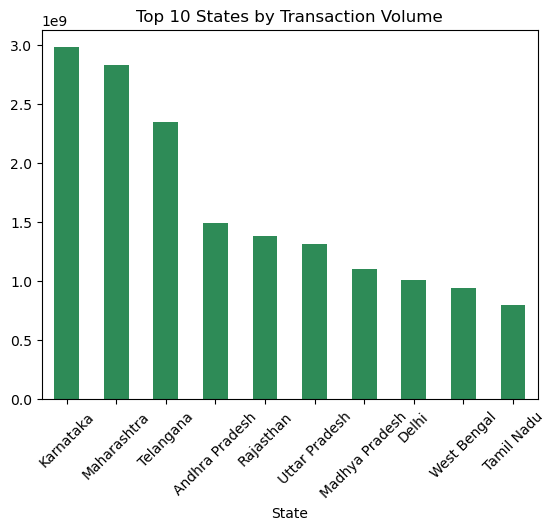

In [113]:
# Visualization:
state_txn.head(10).plot(kind='bar', color='seagreen')
plt.xticks(rotation=45)
plt.title('Top 10 States by Transaction Volume')
plt.show()

In [99]:
# 3. Top States by Transaction Value 
# Business Insight: Which states contribute the most payment value?
 
state_amount = (
    df_State_Txn_Users
    .groupby('State')['Amount (INR)']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_amount.head(10)

,State,Amount (INR)
0,Telangana,4.574246e+12
1,Karnataka,4.361396e+12
2,Maharashtra,4.290995e+12
3,Andhra Pradesh,3.187847e+12
4,Rajasthan,2.625584e+12
5,Uttar Pradesh,2.399757e+12
6,Madhya Pradesh,1.915101e+12
7,Delhi,1.649942e+12
8,Bihar,1.639579e+12
9,Tamil Nadu,1.481448e+12


In [101]:
# 4. Top States by Registered Users
# Question: Which states have the largest PhonePe user base?
state_users = (
    df_State_Txn_Users
    .groupby('State')['Registered Users']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_users.head(10)


,State,Registered Users
0,Maharashtra,315783658
1,Uttar Pradesh,246200404
2,Karnataka,203098564
3,Rajasthan,149770064
4,Telangana,149224214
5,West Bengal,144242183
6,Andhra Pradesh,139644224
7,Tamil Nadu,132437426
8,Gujarat,126380032
9,Madhya Pradesh,125339823


In [102]:
# 5. Top States by App Opens
# Question: Which states show the highest engagement?
state_opens = (
    df_State_Txn_Users
    .groupby('State')['App Opens']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_opens.head(10)

,State,App Opens
0,Maharashtra,6145385557
1,Karnataka,6010582453
2,Telangana,4737814072
3,Andhra Pradesh,4394470138
4,Rajasthan,3914112235
5,Uttar Pradesh,3744913382
6,Madhya Pradesh,2937727396
7,Bihar,2043130469
8,West Bengal,2006508265
9,Odisha,1829219041


In [103]:
# Which states have the most active users?
# This is much stronger than simply showing transaction counts.
df_State_Txn_Users['Transactions per User'] = (
    df_State_Txn_Users['Transactions'] /
    df_State_Txn_Users['Registered Users']
)

In [106]:
df_State_Txn_Users.groupby('State')['Transactions per User']\
                  .mean()\
                  .sort_values(ascending=False)\
                  .reset_index()
                  
df_State_Txn_Users.head(10)                 

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Transactions per User
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,0.987834
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0,1.205742
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0,1.338793
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0,1.560767
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0,1.639385
5,Andaman & Nicobar Islands,2019,2,33689,1.202547e+08,3569.554148,21731,52640,1.550274
6,Andaman & Nicobar Islands,2019,3,33770,1.140718e+08,3377.902757,23931,171107,1.411140
7,Andaman & Nicobar Islands,2019,4,35159,1.368385e+08,3891.991539,25960,177012,1.354353
8,Andaman & Nicobar Islands,2020,1,41298,1.614763e+08,3910.027418,28368,193586,1.455795
9,Andaman & Nicobar Islands,2020,2,62962,1.696450e+08,2694.402996,32710,305072,1.924855


In [107]:
# Second Dataset
df_State_TxnSplit.columns

Index(['State', 'Year', 'Quarter', 'Transaction Type', 'Transactions',
       'Amount (INR)', 'ATV (INR)'],
      dtype='object')

In [114]:
# 1. Which transaction type contributes the highest volume?
txn_type_volume = (
    df_State_TxnSplit
    .groupby('Transaction Type')['Transactions']
    .sum()
    .sort_values(ascending=False)
    
)

txn_type_volume

Transaction Type
Peer-to-peer payments       9161937793
Merchant payments           6959228853
Recharge & bill payments    4245833207
Others                       117964108
Financial Services            47996333
Name: Transactions, dtype: int64

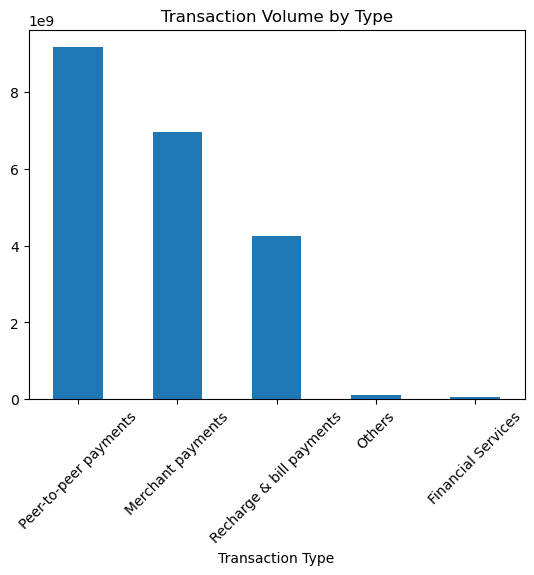

In [118]:
# Visualization:
txn_type_volume.plot(kind='bar')
plt.title('Transaction Volume by Type')
plt.xticks(rotation=45)
plt.show()

In [117]:
# 2. Which transaction type contributes the highest value?
# Business Question: Are users primarily using PhonePe for merchant payments, peer-to-peer transfers, recharge, or bill payments?

txn_type_amount = (
    df_State_TxnSplit
    .groupby('Transaction Type')['Amount (INR)']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

txn_type_amount

,Transaction Type,Amount (INR)
0,Peer-to-peer payments,3.058170e+13
1,Merchant payments,3.864437e+12
2,Recharge & bill payments,1.764807e+12
3,Others,6.890859e+10
4,Financial Services,2.175394e+10


In [125]:
# 3. Most Frequent Transaction Type in Each State
# Question: What payment behavior dominates in each state?

state_txn_type = (
    df_State_TxnSplit
    .groupby(['State','Transaction Type'])['Transactions']
    .sum()
    .reset_index()
)

state_txn_type.loc[
    state_txn_type.groupby('State')['Transactions'].idxmax()
]



,State,Transaction Type,Transactions
4,Andaman & Nicobar Islands,Recharge & bill payments,492641
8,Andhra Pradesh,Peer-to-peer payments,944411081
14,Arunachal Pradesh,Recharge & bill payments,3868464
18,Assam,Peer-to-peer payments,55178220
23,Bihar,Peer-to-peer payments,370640181
28,Chandigarh,Peer-to-peer payments,11132019
33,Chhattisgarh,Peer-to-peer payments,99454667
38,Dadra & Nagar Haveli and Daman & Diu,Peer-to-peer payments,5006285
41,Delhi,Merchant payments,414408596
48,Goa,Peer-to-peer payments,10193184


In [127]:
# 5. Quarterly Trend by Transaction Type
# Question: Which transaction categories are growing fastest over time?
quarterly_type = (
    df_State_TxnSplit
    .groupby(['Year','Quarter','Transaction Type'])['Transactions']
    .sum()
    .reset_index()
)
quarterly_type

,Year,Quarter,Transaction Type,Transactions
0,2018,1,Financial Services,3762820
1,2018,1,Merchant payments,5368663
2,2018,1,Others,5761551
3,2018,1,Peer-to-peer payments,46982534
4,2018,1,Recharge & bill payments,72550031
5,2018,2,Financial Services,5186567
6,2018,2,Merchant payments,10613935
7,2018,2,Others,4973191
8,2018,2,Peer-to-peer payments,74558560
9,2018,2,Recharge & bill payments,92033187


In [128]:
# Third Dataset 
df_State_DeviceData.columns

Index(['State', 'Year', 'Quarter', 'Brand', 'Registered Users', 'Percentage'], dtype='object')

In [132]:
# Business Questions & Insights
# 1. Which Smartphone Brand Dominates PhonePe?
# Insight: Which smartphone brands contribute the most PhonePe users?
brand_users = (
    df_State_DeviceData
    .groupby('Brand')['Registered Users']
    .sum()
    .sort_values(ascending=False)
    
)

brand_users.head(10)

Brand
Xiaomi      615566524
Samsung     480799591
Vivo        411369522
Oppo        283522909
Others      211221642
Realme      134416015
Apple        67132534
Motorola     57086814
OnePlus      44184950
Huawei       43211672
Name: Registered Users, dtype: int64

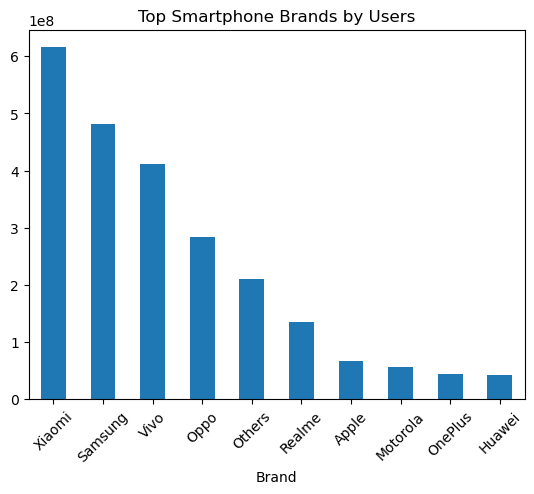

In [135]:
# Visualization: 
brand_users.head(10).plot(kind='bar')
plt.title('Top Smartphone Brands by Users')
plt.xticks(rotation=45)
plt.show()

In [139]:
# 2. Brand Market Share Analysis
# Insight: Which brands have the strongest presence in the PhonePe ecosystem?
brand_share = (
    df_State_DeviceData
    .groupby('Brand')['Percentage']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

brand_share

,Brand,Percentage
0,Xiaomi,0.263382
1,Samsung,0.195330
2,Vivo,0.159304
3,Oppo,0.113420
4,Others,0.095480
5,Realme,0.053866
6,Apple,0.034224
7,Micromax,0.024437
8,OnePlus,0.024254
9,Motorola,0.023192


In [140]:
# 3. Top Brand in Each State
# Insight: Smartphone preferences vary significantly across states.
state_brand = (
    df_State_DeviceData
    .groupby(['State','Brand'])['Registered Users']
    .sum()
    .reset_index()
)

top_brand_state = state_brand.loc[
    state_brand.groupby('State')['Registered Users'].idxmax()
]

top_brand_state

,State,Brand,Registered Users
11,Andaman & Nicobar Islands,Xiaomi,97889
22,Andhra Pradesh,Xiaomi,40061549
34,Arunachal Pradesh,Xiaomi,437803
46,Assam,Xiaomi,6979357
60,Bihar,Xiaomi,33721314
73,Chandigarh,Xiaomi,896628
85,Chhattisgarh,Xiaomi,8763373
98,Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
109,Delhi,Xiaomi,24114984
120,Goa,Xiaomi,1208672


In [141]:
# 4. Brand Diversity Across States
# Question: Are users concentrated on one brand or spread across multiple brands?

df_State_DeviceData.groupby('State')['Brand'].nunique()\
                   .sort_values(ascending=False)

State
Uttar Pradesh                           15
Sikkim                                  15
Manipur                                 15
Jharkhand                               14
Bihar                                   14
Punjab                                  14
Lakshadweep                             13
Uttarakhand                             13
Tripura                                 13
Rajasthan                               13
Nagaland                                13
Meghalaya                               13
Madhya Pradesh                          13
West Bengal                             13
Chandigarh                              13
Himachal Pradesh                        13
Dadra & Nagar Haveli and Daman & Diu    13
Jammu & Kashmir                         12
Mizoram                                 12
Arunachal Pradesh                       12
Assam                                   12
Chhattisgarh                            12
Odisha                                  12
Harya

In [142]:
# 5. Device Adoption Trend
# Question: Which smartphone brands are gaining digital payment users fastest?
device_trend = (
    df_State_DeviceData
    .groupby(['Year','Brand'])['Registered Users']
    .sum()
    .reset_index()
)

In [143]:
# 6. Which states are highly dependent on a single smartphone brand for digital payments?
brand_state = (
    df_State_DeviceData
    .groupby(['State','Brand'])['Registered Users']
    .sum()
    .reset_index()
)
brand_state

,State,Brand,Registered Users
0,Andaman & Nicobar Islands,Apple,9334
1,Andaman & Nicobar Islands,Huawei,11497
2,Andaman & Nicobar Islands,Lenovo,5362
3,Andaman & Nicobar Islands,Motorola,9491
4,Andaman & Nicobar Islands,OnePlus,15397
5,Andaman & Nicobar Islands,Oppo,36007
6,Andaman & Nicobar Islands,Others,33630
7,Andaman & Nicobar Islands,Realme,22546
8,Andaman & Nicobar Islands,Samsung,77065
9,Andaman & Nicobar Islands,Tecno,1770


In [144]:
# Fourth Dataset 
df_District_Txn_Users.columns

Index(['State', 'Year', 'Quarter', 'District', 'Code', 'Transactions',
       'Amount (INR)', 'ATV (INR)', 'Registered Users', 'App Opens'],
      dtype='object')

In [147]:
# 1. Top 20 Districts by Transaction Volume
# Business Insight:Which districts contribute the highest transaction activity?

top_district_txn = (
    df_District_Txn_Users
    .groupby('District')['Transactions']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_district_txn.head(20)

,District,Transactions
0,Bengaluru Urban,2002185867
1,Pune,1092713069
2,Hyderabad,966222353
3,Jaipur,658951877
4,Rangareddy,353740183
5,Visakhapatnam,308797503
6,Medchal Malkajgiri,307913214
7,Bhopal,307828868
8,Central,292450234
9,Khordha,272070730


In [149]:
# 2. Top 20 Districts by Transaction Value
# Insight: Which districts generate the highest payment value?
top_district_amount = (
    df_District_Txn_Users
    .groupby('District')['Amount (INR)']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_district_amount.head(20)

,District,Amount (INR)
0,Bengaluru Urban,2.566575e+12
1,Hyderabad,1.897550e+12
2,Pune,1.419771e+12
3,Jaipur,1.195805e+12
4,Visakhapatnam,5.836211e+11
5,Rangareddy,5.752253e+11
6,Patna,5.115510e+11
7,Bhopal,4.955893e+11
8,Medchal Malkajgiri,4.906344e+11
9,Central,4.873861e+11


In [151]:
# 3. Top Districts by Registered Users
top_users = (
    df_District_Txn_Users
    .groupby('District')['Registered Users']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_users.head(20)

,District,Registered Users
0,Bengaluru Urban,89918328
1,Pune,57175792
2,Jaipur,36314044
3,Thane,34505411
4,Mumbai Suburban,34421720
5,Hyderabad,29843436
6,Ahmadabad,26575415
7,Rangareddy,26256366
8,Medchal Malkajgiri,22391313
9,Surat,21745487


In [154]:
# 4. Top Districts by App Engagement
# Question: Which districts show the highest engagement with PhonePe?
top_opens = (
    df_District_Txn_Users
    .groupby('District')['App Opens']
    .sum()
    .sort_values(ascending=False)
    
)

top_opens.head(20)

District
Bengaluru Urban        2929941673
Pune                   1340057624
Jaipur                  994862916
Hyderabad               818057396
Rangareddy              812998226
Visakhapatnam           764051990
Medchal Malkajgiri      708893607
Chittoor                556901117
Thane                   493836441
East Godavari           488840551
Guntur                  487840444
Krishna                 486150466
Gurugram                443688901
Anantapur               439005860
Mumbai Suburban         429467926
Gautam Buddha Nagar     420602417
Nashik                  415606600
Kurnool                 386212361
Aurangabad              374763535
Ahmadabad               360997730
Name: App Opens, dtype: int64

In [155]:
# * 5.Transactions per User
df_District_Txn_Users['Transactions_per_User'] = (
    df_District_Txn_Users['Transactions'] /
    df_District_Txn_Users['Registered Users']
)

In [156]:
# Which districts have the most active users?
df_District_Txn_Users.groupby('District')['Transactions_per_User']\
                     .mean()\
                     .sort_values(ascending=False)\
                     .head(20)

District
Poonch                68.422714
Central               27.038893
Hyderabad             25.542698
Washim                21.933302
New Delhi             20.699128
Bhopal                20.082492
Bengaluru Urban       18.378816
Khordha               17.482771
Pune                  15.168317
Jaipur                14.572594
Chennai               13.115004
Kolkata               12.369120
Visakhapatnam         11.849148
Birbhum               11.488138
Rangareddy            11.134774
Medchal Malkajgiri    11.125086
Patna                 11.103866
Warangal Urban        10.906610
Senapati              10.814468
Spsr Nellore          10.477567
Name: Transactions_per_User, dtype: float64

In [157]:
# Amount per User
# Which districts generate the highest value per user?

df_District_Txn_Users['Amount_per_User'] = (
    df_District_Txn_Users['Amount (INR)'] /
    df_District_Txn_Users['Registered Users']
)

In [174]:
df_District_Txn_Users.groupby('District')['Amount_per_User']\
                     .mean()\
                     .sort_values(ascending=False)
df_District_Txn_Users.head(20)                    

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Transactions_per_User,Amount_per_User,Opens_per_User
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0,2.015267,4350.567944,0.000000
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0,0.699367,1474.150438,0.000000
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,0.972973,2148.520244,0.000000
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0,3.190883,8753.381505,0.000000
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0,0.905598,1446.611508,0.000000
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0,1.153752,2940.959783,0.000000
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0,3.149893,13678.435014,0.000000
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0,1.062086,4057.557548,0.000000
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0,1.289956,4226.476271,0.000000
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0,2.770522,13397.125662,0.000000


In [176]:
#   Question:
# Question: Which districts have the most engaged users?

df_District_Txn_Users['Opens_per_User'] = (
    df_District_Txn_Users['App Opens'] /
    df_District_Txn_Users['Registered Users']
)


In [161]:
# 5th Dataset 
df_District_Demographics.columns

Index(['State', 'District', 'Headquarters', 'Population', 'Area (sq km)',
       'Density', 'Code', 'Alternate Name'],
      dtype='object')

In [163]:
# Phase 1: State-Level Analysis
# Question 1 : Which states contribute the highest transaction volume?
state_txn = (
    df_State_Txn_Users
    .groupby('State')['Transactions']
    .sum()
    .sort_values(ascending=False)
)
state_txn

State
Karnataka                               2981044533
Maharashtra                             2833670154
Telangana                               2347430243
Andhra Pradesh                          1491343199
Rajasthan                               1382918930
Uttar Pradesh                           1314714390
Madhya Pradesh                          1100253728
Delhi                                   1011031124
West Bengal                              942286041
Tamil Nadu                               800399873
Odisha                                   740479146
Bihar                                    713643889
Gujarat                                  612992823
Haryana                                  567751410
Jharkhand                                275270987
Chhattisgarh                             241908549
Kerala                                   223637876
Punjab                                   181336904
Uttarakhand                              124011162
Assam                    

In [164]:
# Question 3 Which states have the highest user base?
state_users = (
    df_State_Txn_Users
    .groupby('State')['Registered Users']
    .sum()
    .sort_values(ascending=False)
)

state_users

State
Maharashtra                             315783658
Uttar Pradesh                           246200404
Karnataka                               203098564
Rajasthan                               149770064
Telangana                               149224214
West Bengal                             144242183
Andhra Pradesh                          139644224
Tamil Nadu                              132437426
Gujarat                                 126380032
Madhya Pradesh                          125339823
Bihar                                   115284760
Delhi                                    95374654
Haryana                                  85564119
Odisha                                   80404103
Kerala                                   51267042
Punjab                                   45811761
Jharkhand                                44768682
Chhattisgarh                             37448388
Assam                                    26860751
Uttarakhand                              237

In [165]:
# Question 4 Which states have the highest engagement?
state_opens = (
    df_State_Txn_Users
    .groupby('State')['App Opens']
    .sum()
    .sort_values(ascending=False)
)

In [166]:
# Phase 2: Growth Analysis 

df_State_Txn_Users['Period'] = (
    df_State_Txn_Users['Year'].astype(str)
    + '-Q'
    + df_State_Txn_Users['Quarter'].astype(str)
)

In [170]:
# Question 5 How have transactions grown over time?
quarterly_txn = (
    df_State_Txn_Users
    .groupby(['Year','Quarter'])['Transactions']
    .sum()
   
)

quarterly_txn

Year  Quarter
2018  1           134425599
      2           187365440
      3           341299764
      4           417111607
2019  1           708992981
      2           815380896
      3          1095009675
      4          1460443663
2020  1          1623038046
      2          1448608890
      3          2033051183
      4          2869276622
2021  1          3167837493
      2          3941370465
Name: Transactions, dtype: int64

In [175]:
# Demographic Analysis ⭐

# This is the section that makes the project stand out.

# Merge:

district_final = pd.merge(
    df_District_Txn_Users,
    df_District_Demographics,
    on=['State','District','Code'],
    how='left'
)


In [172]:
# Phase 8: Correlation Analysis

# Create:

corr_cols = [
    'Population',
    'Density',
    'Transactions',
    'Amount (INR)',
    'Registered Users',
    'App Opens'
]


In [173]:
district_final[corr_cols].corr()

,Population,Density,Transactions,Amount (INR),Registered Users,App Opens
Population,1.000000,0.304186,0.359150,0.350648,0.657376,0.422508
Density,0.304186,1.000000,0.307676,0.336765,0.301351,0.165528
Transactions,0.359150,0.307676,1.000000,0.974353,0.841699,0.892122
Amount (INR),0.350648,0.336765,0.974353,1.000000,0.830314,0.871135
Registered Users,0.657376,0.301351,0.841699,0.830314,1.000000,0.860043
App Opens,0.422508,0.165528,0.892122,0.871135,0.860043,1.000000


In [177]:
"""                                                      Visualizations                                                                        """      

'                                                      Visualizations                                                                        '

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

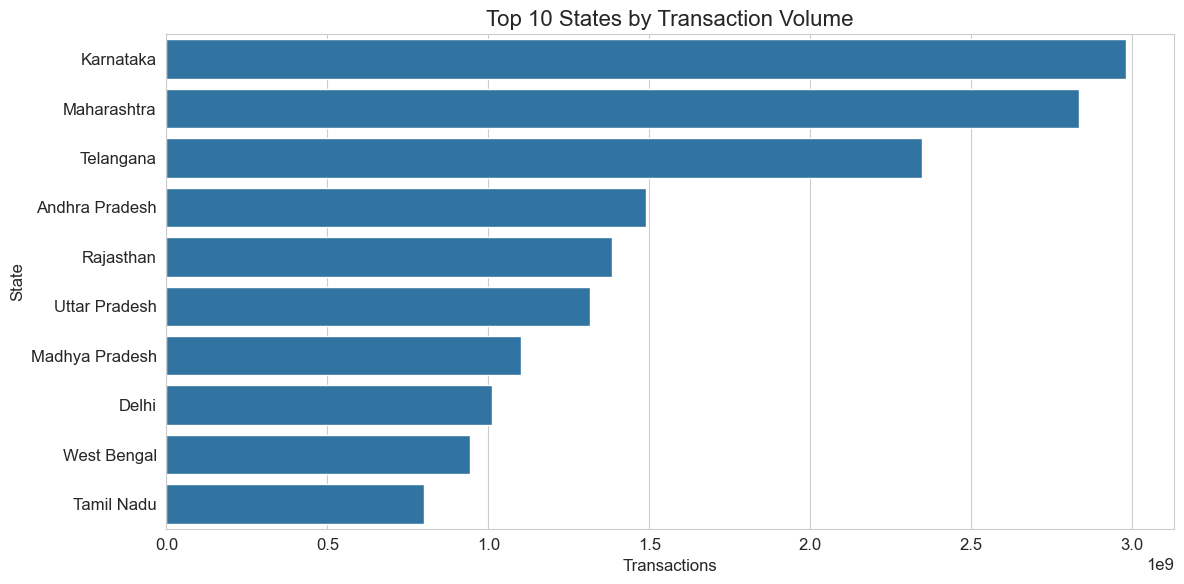

In [181]:
# V.1 Top 10 States by Transaction Volume
top10_txn = state_txn.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_txn.values,
    y=top10_txn.index
)

plt.title('Top 10 States by Transaction Volume')
plt.xlabel('Transactions')
plt.ylabel('State')

plt.tight_layout()
plt.show()

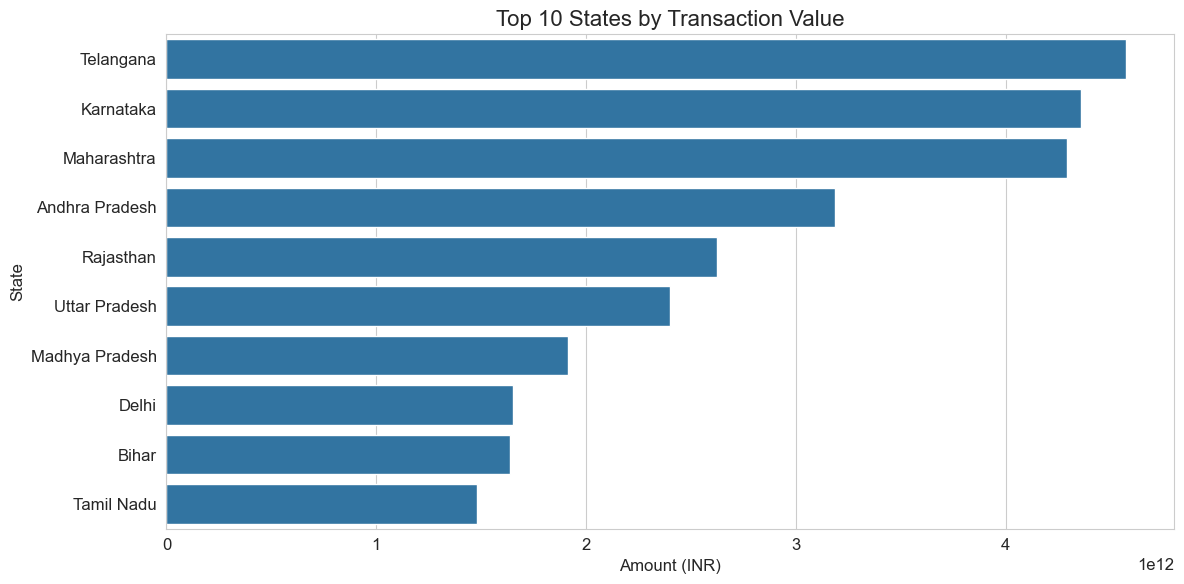

In [184]:
# V 2. Top 10 States by Transaction Value

top10_amount = (
    state_amount
    .head(10)
    .reset_index()
)

top10_amount

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_amount,
    x='Amount (INR)',
    y='State'
)

plt.title('Top 10 States by Transaction Value')
plt.xlabel('Amount (INR)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [185]:
# V 3. Quarterly Transaction Trend. This is one of the most important charts in your project.
quarterly_txn = (
    df_State_Txn_Users
    .groupby(['Year','Quarter'])['Transactions']
    .sum()
    .reset_index()
)

quarterly_txn['Period'] = (
    quarterly_txn['Year'].astype(str)
    + '-Q'
    + quarterly_txn['Quarter'].astype(str)
)


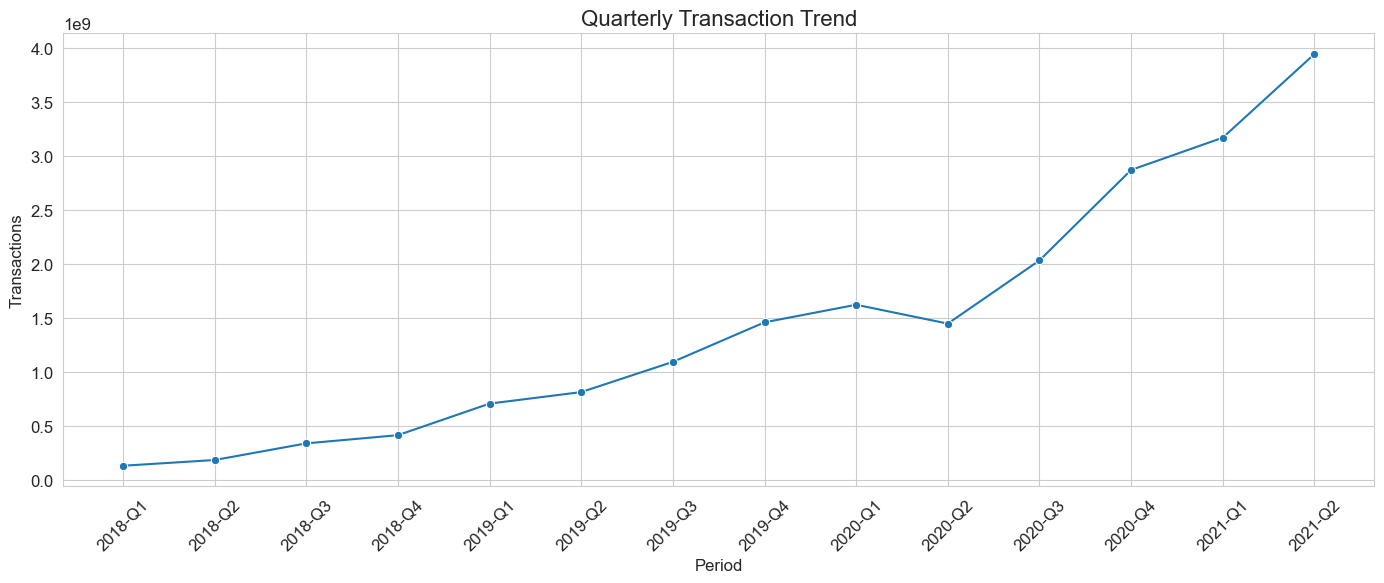

In [188]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=quarterly_txn,
    x='Period',
    y='Transactions',
    marker='o'
)

plt.title('Quarterly Transaction Trend')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [189]:
# Transaction Type Share. This chart tells a business story.
txn_type = (
    df_State_TxnSplit
    .groupby('Transaction Type')['Transactions']
    .sum()
    .sort_values(ascending=False)
)

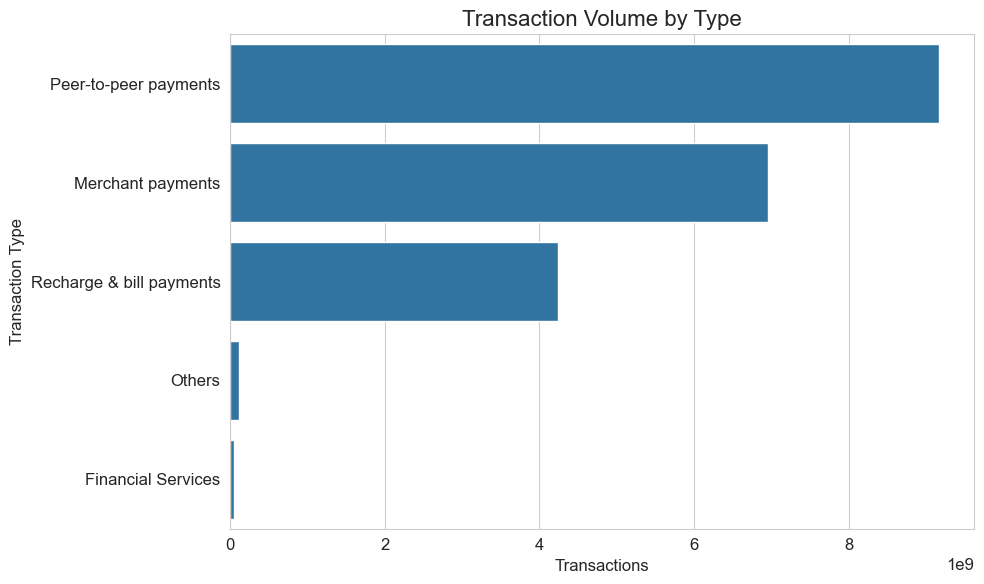

In [190]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=txn_type.values,
    y=txn_type.index
)

plt.title('Transaction Volume by Type')
plt.xlabel('Transactions')
plt.ylabel('Transaction Type')

plt.tight_layout()
plt.show()

In [191]:
# Correlation Heatmap
corr_cols = [
    'Population',
    'Density',
    'Transactions',
    'Amount (INR)',
    'Registered Users',
    'App Opens'
]

corr_matrix = district_final[corr_cols].corr()

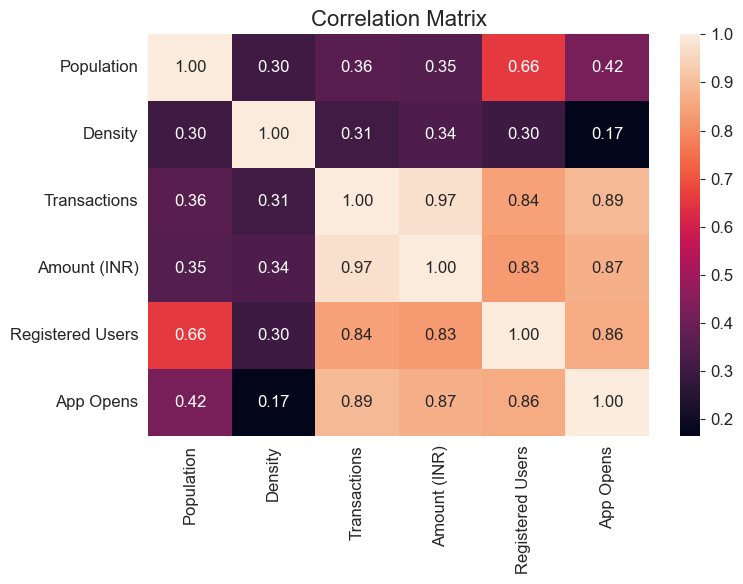

In [192]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [193]:
# Top Districts by Transactions
top_districts = (
    df_District_Txn_Users
    .groupby('District')['Transactions']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

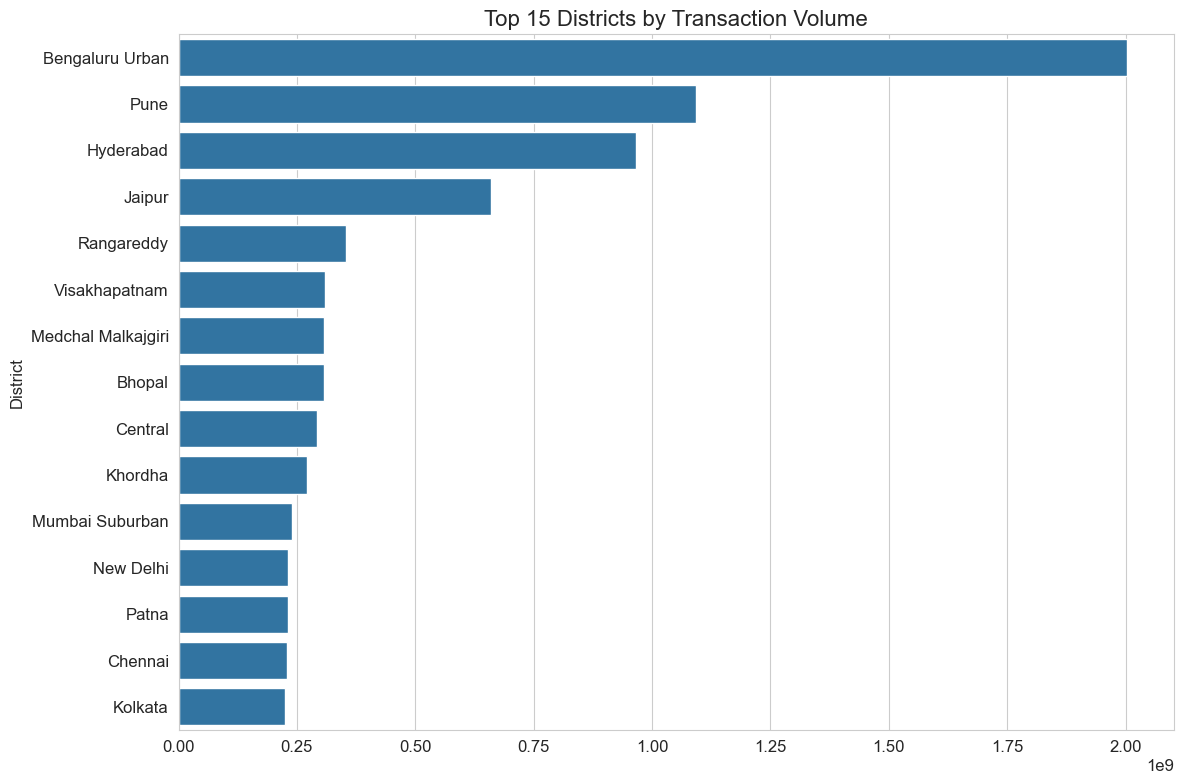

In [194]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=top_districts.values,
    y=top_districts.index
)

plt.title('Top 15 Districts by Transaction Volume')

plt.tight_layout()
plt.show()

In [196]:
# Population vs Registered Users
district_final = pd.merge(
    df_District_Txn_Users,
    df_District_Demographics,
    on=['State', 'District', 'Code'],
    how='left'
)

In [197]:
# Aggregate at district level to avoid duplicate points:
scatter_df = (
    district_final
    .groupby(['State', 'District'], as_index=False)
    .agg({
        'Population': 'first',
        'Registered Users': 'max'
    })
)

scatter_df.head()

,State,District,Population,Registered Users
0,Andaman & Nicobar Islands,Nicobars,NaN,1699
1,Andaman & Nicobar Islands,North And Middle Andaman,NaN,8493
2,Andaman & Nicobar Islands,South Andaman,238142.0,51903
3,Andhra Pradesh,Anantapur,4083315.0,1492738
4,Andhra Pradesh,Chittoor,4170468.0,1870723


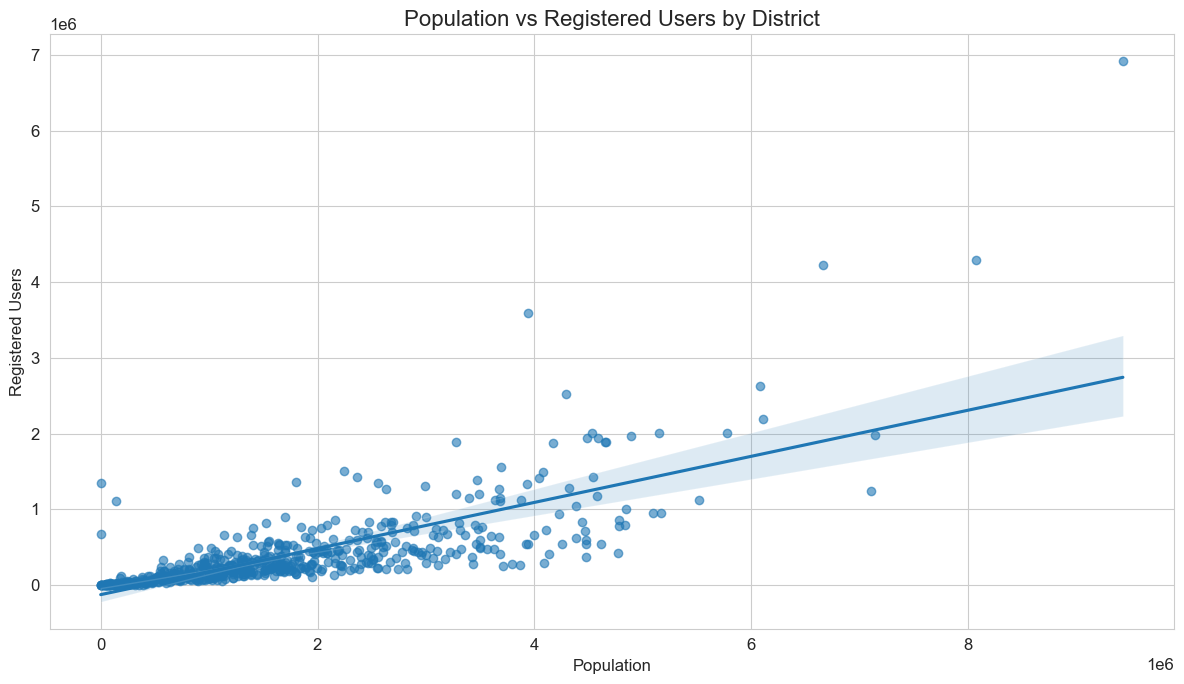

In [198]:
plt.figure(figsize=(12, 7))

sns.regplot(
    data=scatter_df,
    x='Population',
    y='Registered Users',
    scatter_kws={'alpha': 0.6}
)

plt.title('Population vs Registered Users by District')
plt.xlabel('Population')
plt.ylabel('Registered Users')

plt.tight_layout()
plt.show()